# 동물상 분류 모델 데이터
- 최소 데이터: 20개 클래스, 50장씩


## 1. 데이터 준비

### 1) 데이터 수집

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, models, transforms
import numpy as np
import time

In [ ]:
from bing_image_downloader import downloader

downloader.download(
    query="알파카상",             # 검색어
    limit=50,
    output_dir="./dataset/raw",     # 파일 저장 위치
    adult_filter_off=True,
    force_replace=False,
    timeout=30 
)

downloader.download(
    query="공룡상",             # 검색어
    limit=50,
    output_dir="./dataset/raw",     # 파일 저장 위치
    adult_filter_off=True,
    force_replace=False,
    timeout=30 
)

downloader.download(
    query="원숭이상",             # 검색어
    limit=50,
    output_dir="./dataset/raw",     # 파일 저장 위치
    adult_filter_off=True,
    force_replace=False,
    timeout=30 
)

downloader.download(
    query="오리상",             # 검색어
    limit=50,
    output_dir="./dataset/raw",     # 파일 저장 위치
    adult_filter_off=True,
    force_replace=False,
    timeout=30 
)

downloader.download(
    query="코알라상",             # 검색어
    limit=50,
    output_dir="./dataset/raw",     # 파일 저장 위치
    adult_filter_off=True,
    force_replace=False,
    timeout=30 
)

downloader.download(
    query="늑대상",             # 검색어
    limit=50,
    output_dir="./dataset/raw",     # 파일 저장 위치
    adult_filter_off=True,
    force_replace=False,
    timeout=30 
)

downloader.download(
    query="햄스터상",             # 검색어
    limit=50,
    output_dir="./dataset/raw",     # 파일 저장 위치
    adult_filter_off=True,
    force_replace=False,
    timeout=30 
)

downloader.download(
    query="꽃돼지상",             # 검색어
    limit=50,
    output_dir="./dataset/raw",     # 파일 저장 위치
    adult_filter_off=True,
    force_replace=False,
    timeout=30 
)

downloader.download(
    query="너구리상",             # 검색어
    limit=50,
    output_dir="./dataset/raw",     # 파일 저장 위치
    adult_filter_off=True,
    force_replace=False,
    timeout=30 
)

downloader.download(
    query="말상",             # 검색어
    limit=50,
    output_dir="./dataset/raw",     # 파일 저장 위치
    adult_filter_off=True,
    force_replace=False,
    timeout=30 
)

### 2) 얼굴 추출
- 1) dataset/raw/<클래스>/(클래스당 70장)에서 이미지를 읽어 얼굴을 검출하고, 검출되면 랜드마크 기반으로 112×112 정렬 크롭(norm_crop)을 생성
    - 얼굴 검출/정렬이 실패한 이미지는 중앙 크롭 후 112×112로 리사이즈하여 대체
- 2) 검출 점수(det_score)와 정렬 성공 여부를 기반으로 점수를 매겨 클래스당 상위 50장을 dataset/selected50/<클래스>/에 저장

In [ ]:
import cv2, numpy as np, random
from pathlib import Path
from insightface.app import FaceAnalysis
from insightface.utils.face_align import norm_crop

# 유니코드 경로 읽기/쓰기 
def imread_unicode(path: Path):
    data = np.fromfile(str(path), dtype=np.uint8)
    return cv2.imdecode(data, cv2.IMREAD_COLOR)

def imwrite_unicode_jpg(path: Path, img):
    path.parent.mkdir(parents=True, exist_ok=True)
    ok, buf = cv2.imencode(".jpg", img)
    if not ok:
        raise RuntimeError(f"imencode failed: {path}")
    buf.tofile(str(path))

def center_square_resize(img, size=112):
    h, w = img.shape[:2]
    s = min(h, w)
    y1 = (h - s) // 2
    x1 = (w - s) // 2
    crop = img[y1:y1+s, x1:x1+s]
    return cv2.resize(crop, (size, size), interpolation=cv2.INTER_AREA)

IMG_EXTS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

# 설정
RAW_DIR = Path("dataset/raw")             # 클래스당 70장
SELECTED_DIR = Path("dataset/selected50") # 클래스당 50장 저장
TARGET_PER_CLASS = 50
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

# 검출률 높이기
app = FaceAnalysis(name="buffalo_l")
app.prepare(ctx_id=0, det_size=(1280, 1280), det_thresh=0.1)

def detect_best_face(app, img):
    # 1) 원본
    faces = app.get(img)
    if faces:
        face = max(faces, key=lambda f: (f.bbox[2]-f.bbox[0])*(f.bbox[3]-f.bbox[1]))
        return face, img

    # 2) padding
    h, w = img.shape[:2]
    pad = int(0.25 * max(h, w))
    img_pad = cv2.copyMakeBorder(img, pad, pad, pad, pad, cv2.BORDER_CONSTANT, value=(0, 0, 0))
    faces = app.get(img_pad)
    if faces:
        face = max(faces, key=lambda f: (f.bbox[2]-f.bbox[0])*(f.bbox[3]-f.bbox[1]))
        return face, img_pad

    # 3) upsample
    scale = 1.5
    img_up = cv2.resize(img, (int(w*scale), int(h*scale)), interpolation=cv2.INTER_CUBIC)
    faces = app.get(img_up)
    if faces:
        face = max(faces, key=lambda f: (f.bbox[2]-f.bbox[0])*(f.bbox[3]-f.bbox[1]))
        return face, img_up

    return None, img

# raw(70) -> selected50(50)
SELECTED_DIR.mkdir(parents=True, exist_ok=True)

for cls_dir in [d for d in RAW_DIR.iterdir() if d.is_dir()]:
    imgs = [p for p in cls_dir.iterdir() if p.is_file() and p.suffix.lower() in IMG_EXTS]
    if not imgs:
        print(f"[WARN] no images: {cls_dir.name}")
        continue

    random.shuffle(imgs)

    candidates = []  # (score, cropped112, src_path)
    for p in imgs:
        img = imread_unicode(p)
        if img is None:
            continue

        face, used_img = detect_best_face(app, img)

        if face is not None and getattr(face, "kps", None) is not None:
            out = norm_crop(used_img, face.kps)  # 112x112
            det_score = float(getattr(face, "det_score", 0.0))
            score = det_score + 1.0  # aligned 보너스
        else:
            out = center_square_resize(img, 112)
            score = 0.0  # fallback는 낮게

        candidates.append((score, out, p))

    if len(candidates) < TARGET_PER_CLASS:
        print(f"[WARN] {cls_dir.name}: candidates={len(candidates)} < target={TARGET_PER_CLASS} (그래도 진행)")

    candidates.sort(key=lambda x: x[0], reverse=True)
    selected = candidates[:TARGET_PER_CLASS]

    out_cls = SELECTED_DIR / cls_dir.name
    out_cls.mkdir(parents=True, exist_ok=True)

    for i, (score, out_img, src) in enumerate(selected, start=1):
        out_name = f"{cls_dir.name}_{i:03d}.jpg"
        imwrite_unicode_jpg(out_cls / out_name, out_img)

    print(f"selected50 {cls_dir.name}: selected={len(selected)} (top_score={selected[0][0] if selected else None})")

print("\nStep1 done:", SELECTED_DIR.resolve())

### 3) train / test 분리
- 1) dataset/selected50/<클래스>/의 이미지를 클래스별로 셔플한 뒤 80/20(train/test)로 분리
- 2) dataset/train/<클래스>/, dataset/test/<클래스>/에 복사

In [2]:
import random, shutil
from pathlib import Path

# 설정
SELECTED_DIR = Path("dataset/selected50")
TRAIN_DIR    = Path("dataset/train")
TEST_DIR     = Path("dataset/test")

TRAIN_RATIO = 0.8
SEED = 42
COPY_MODE = True         # True=복사, False=이동
CLEAR_OUTPUT = True      # train/test 폴더를 비우고 다시 생성

IMG_EXTS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

random.seed(SEED)

def copy_or_move(src: Path, dst: Path):
    dst.parent.mkdir(parents=True, exist_ok=True)
    if COPY_MODE:
        shutil.copy2(src, dst)   # 동일 파일명 있으면 덮어씀
    else:
        shutil.move(str(src), str(dst))

def clear_dir(path: Path):
    if path.exists():
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)

def split_train_test(paths, train_ratio=0.8):
    paths = list(paths)
    random.shuffle(paths)
    n = len(paths)
    n_train = int(n * train_ratio)
    if n >= 2:
        n_train = min(max(n_train, 1), n - 1)  # 최소 1장씩은 배정
    return paths[:n_train], paths[n_train:]

# 실행
if not SELECTED_DIR.exists():
    raise FileNotFoundError(f"Not found: {SELECTED_DIR.resolve()}")

if CLEAR_OUTPUT:
    clear_dir(TRAIN_DIR)
    clear_dir(TEST_DIR)

for cls_dir in [d for d in SELECTED_DIR.iterdir() if d.is_dir()]:
    imgs = [p for p in cls_dir.iterdir() if p.is_file() and p.suffix.lower() in IMG_EXTS]
    if not imgs:
        print(f"[WARN] no images: {cls_dir.name}")
        continue

    train_list, test_list = split_train_test(imgs, TRAIN_RATIO)

    for src in train_list:
        copy_or_move(src, TRAIN_DIR / cls_dir.name / src.name)

    for src in test_list:
        copy_or_move(src, TEST_DIR / cls_dir.name / src.name)

    print(f"split {cls_dir.name}: total={len(imgs)}, train={len(train_list)}, test={len(test_list)}")

print("\nDone!")
print("Train:", TRAIN_DIR.resolve())
print("Test :", TEST_DIR.resolve())

split 강아지상: total=50, train=40, test=10
split 고양이상: total=50, train=40, test=10
split 곰상: total=50, train=40, test=10
split 공룡상: total=50, train=40, test=10
split 꼬부기상: total=50, train=40, test=10
split 꽃돼지상: total=50, train=40, test=10
split 너구리상: total=50, train=40, test=10
split 늑대상: total=50, train=40, test=10
split 도롱뇽상: total=50, train=40, test=10
split 말상: total=50, train=40, test=10
split 사슴상: total=50, train=40, test=10
split 알파카상, 라마상: total=50, train=40, test=10
split 여우상: total=50, train=40, test=10
split 오리상: total=50, train=40, test=10
split 원숭이: total=50, train=40, test=10
split 쥐상: total=50, train=40, test=10
split 코알라상: total=50, train=40, test=10
split 쿼카상: total=50, train=40, test=10
split 토끼상: total=50, train=40, test=10
split 햄스터상: total=50, train=40, test=10

Done!
Train: C:\workspace\project2\gachikium\유현희\dataset\train
Test : C:\workspace\project2\gachikium\유현희\dataset\test


### 4) ArcFace 임베딩

In [3]:
import cv2, numpy as np
from pathlib import Path
from insightface.app import FaceAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

IMG_EXTS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}
TRAIN_DIR = Path("dataset/train")
TEST_DIR  = Path("dataset/test")

# 1) buffalo_l 로드
app = FaceAnalysis(name="buffalo_l")
app.prepare(ctx_id=0, det_size=(640, 640))   # GPU면 0, CPU면 -1

# 2) ArcFace 임베딩 모델 꺼내기
rec = app.models.get("recognition")
if rec is None:
    raise RuntimeError(f"recognition model not found. keys={list(app.models.keys())}")

# 유니코드 경로 읽기
def imread_unicode(path: Path):
    data = np.fromfile(str(path), dtype=np.uint8)
    return cv2.imdecode(data, cv2.IMREAD_COLOR)

# L2 정규화
def l2_normalize(x):
    return x / (np.linalg.norm(x) + 1e-12)

# 112x112 얼굴 이미지 -> 512차원 임베딩
def get_embedding_112_bgr(img_bgr_112):
    if hasattr(rec, "get_feat"):
        emb = rec.get_feat(img_bgr_112)
    else:
        raise RuntimeError(f"rec has no get_feat(). available: {dir(rec)}")

    emb = np.asarray(emb).reshape(-1)
    return l2_normalize(emb).astype(np.float32)

# train/test 폴더 이미지를 임베딩으로 변환
# 학습 데이터는 기존 방식 유지: 이미 얼굴 추출된 이미지라고 보고 112x112로만 맞춤
def load_split_embeddings(root_dir: Path):
    X, y = [], []
    classes = sorted([d.name for d in root_dir.iterdir() if d.is_dir()])
    class_to_idx = {c: i for i, c in enumerate(classes)}

    for cls in classes:
        cls_dir = root_dir / cls
        files = sorted(
            [p for p in cls_dir.iterdir() if p.is_file() and p.suffix.lower() in IMG_EXTS],
            key=lambda p: p.name
        )

        for p in files:
            img = imread_unicode(p)
            if img is None:
                continue

            if img.shape[0] != 112 or img.shape[1] != 112:
                img = cv2.resize(img, (112, 112), interpolation=cv2.INTER_AREA)

            X.append(get_embedding_112_bgr(img))
            y.append(class_to_idx[cls])

    return np.vstack(X), np.array(y), classes

Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CUDAExecutionProvider': {'device_id': '0', 'has_user_compute_stream': '0', 'cudnn_conv1d_pad_to_nc1d': '0', 'user_compute_stream': '0', 'gpu_external_alloc': '0', 'gpu_mem_limit': '18446744073709551615', 'enable_cuda_graph': '0', 'gpu_external_free': '0', 'gpu_external_empty_cache': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'do_copy_in_default_stream': '1', 'cudnn_conv_use_max_workspace': '1', 'tunable_op_enable': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'prefer_nhwc': '0', 'use_ep_level_unified_stream': '0', 'use_tf32': '1', 'sdpa_kernel': '0', 'fuse_conv_bias': '0'}, 'CPUExecutionProvider': {}}
find model: C:\Users\user/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider']

## 2. 분류기 학습/평가

### 1) 평가 함수

In [4]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def evaluate(clf, X_test, y_test, classes):
    pred = clf.predict(X_test)
    acc = accuracy_score(y_test, pred)
    print("Test Accuracy:", acc)

    print("\n[Classification Report]")
    print(classification_report(y_test, pred, target_names=classes))

    print("\n[Confusion Matrix]")
    print(confusion_matrix(y_test, pred))

### 2) LogisticRegression

In [5]:
# 데이터 준비
X_train, y_train, classes = load_split_embeddings(TRAIN_DIR)
X_test,  y_test,  _       = load_split_embeddings(TEST_DIR)

print("X_train:", X_train.shape, "X_test:", X_test.shape, "num_classes:", len(classes))

def train_logistic(X_train, y_train):
    clf = LogisticRegression(max_iter=5000)
    clf.fit(X_train, y_train)
    return clf

log_clf = train_logistic(X_train, y_train)

print("[LogisticRegression 결과]")
evaluate(log_clf, X_test, y_test, classes)

X_train: (800, 512) X_test: (200, 512) num_classes: 20
[LogisticRegression 결과]
Test Accuracy: 0.865

[Classification Report]
              precision    recall  f1-score   support

        강아지상       0.50      0.40      0.44        10
        고양이상       1.00      0.80      0.89        10
          곰상       0.77      1.00      0.87        10
         공룡상       1.00      0.90      0.95        10
        꼬부기상       0.67      0.80      0.73        10
        꽃돼지상       0.83      1.00      0.91        10
        너구리상       0.86      0.60      0.71        10
         늑대상       0.91      1.00      0.95        10
        도롱뇽상       1.00      0.90      0.95        10
          말상       1.00      1.00      1.00        10
         사슴상       0.75      0.90      0.82        10
   알파카상, 라마상       1.00      0.70      0.82        10
         여우상       0.83      1.00      0.91        10
         오리상       1.00      1.00      1.00        10
         원숭이       1.00      1.00      1.00        10
          

### 3) LinearSVC

In [6]:
def train_linear_svm(X_train, y_train):
    clf = LinearSVC()
    clf.fit(X_train, y_train)
    return clf

svm_clf = train_linear_svm(X_train, y_train)

print("[LinearSVC 결과]")
evaluate(svm_clf, X_test, y_test, classes)

[LinearSVC 결과]
Test Accuracy: 0.905

[Classification Report]
              precision    recall  f1-score   support

        강아지상       0.73      0.80      0.76        10
        고양이상       0.89      0.80      0.84        10
          곰상       0.91      1.00      0.95        10
         공룡상       0.90      0.90      0.90        10
        꼬부기상       0.80      0.80      0.80        10
        꽃돼지상       0.91      1.00      0.95        10
        너구리상       0.88      0.70      0.78        10
         늑대상       1.00      1.00      1.00        10
        도롱뇽상       1.00      0.90      0.95        10
          말상       1.00      1.00      1.00        10
         사슴상       0.75      0.90      0.82        10
   알파카상, 라마상       1.00      0.80      0.89        10
         여우상       0.91      1.00      0.95        10
         오리상       1.00      1.00      1.00        10
         원숭이       1.00      1.00      1.00        10
          쥐상       0.83      1.00      0.91        10
        코알라상       1

## 3. 하이퍼파라미터 튜닝

### 1) ArcFace 임베딩 기반 Logistic Regression / LinearSVC 최적화

In [7]:
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

X = X_train
y = y_train

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial):
    model_type = trial.suggest_categorical("model", ["logreg", "linearsvc"])
    C = trial.suggest_float("C", 1e-3, 1e3, log=True)
    use_pca = trial.suggest_categorical("use_pca", [False, True])

    n_splits = cv.get_n_splits()
    n_train_fold_min = int(np.floor(X.shape[0] * (n_splits - 1) / n_splits))
    max_pca = min(X.shape[1], n_train_fold_min - 1)
    max_pca = (max_pca // 64) * 64

    steps = [("scaler", StandardScaler())]

    if use_pca and max_pca >= 64:
        n_components = trial.suggest_int("pca_dim", 64, max_pca, step=64)
        steps.append((
            "pca",
            PCA(
                n_components=n_components,
                random_state=42,
                svd_solver="randomized"
            )
        ))
    else:
        steps.append(("pca", "passthrough"))

    if model_type == "logreg":
        clf = LogisticRegression(
            C=C,
            max_iter=5000,
            class_weight="balanced"
        )
    else:
        clf = LinearSVC(
            C=C,
            class_weight="balanced",
            max_iter=5000
        )

    steps.append(("clf", clf))
    pipe = Pipeline(steps)

    return cross_val_score(pipe, X, y, cv=cv, scoring="accuracy").mean()

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("Best score:", study.best_value)
print("Best params:", study.best_params)

[I 2026-03-10 17:49:22,159] A new study created in memory with name: no-name-89fc9ef8-4cbd-4ccc-9c5f-1681354e4e9a


[I 2026-03-10 17:49:24,706] Trial 0 finished with value: 0.82 and parameters: {'model': 'linearsvc', 'C': 0.03689152148693644, 'use_pca': True, 'pca_dim': 320}. Best is trial 0 with value: 0.82.
[I 2026-03-10 17:49:29,470] Trial 1 finished with value: 0.7899999999999999 and parameters: {'model': 'linearsvc', 'C': 0.454171985180684, 'use_pca': True, 'pca_dim': 192}. Best is trial 0 with value: 0.82.
[I 2026-03-10 17:49:31,669] Trial 2 finished with value: 0.7937500000000001 and parameters: {'model': 'linearsvc', 'C': 250.05835451046792, 'use_pca': False}. Best is trial 0 with value: 0.82.
[I 2026-03-10 17:49:33,346] Trial 3 finished with value: 0.7662500000000001 and parameters: {'model': 'linearsvc', 'C': 676.885140451114, 'use_pca': True, 'pca_dim': 256}. Best is trial 0 with value: 0.82.
[I 2026-03-10 17:49:36,606] Trial 4 finished with value: 0.8450000000000001 and parameters: {'model': 'logreg', 'C': 256.1293525254643, 'use_pca': False}. Best is trial 4 with value: 0.84500000000000

Best score: 0.85
Best params: {'model': 'logreg', 'C': 3.2890321836905523, 'use_pca': False}


- Best score: 0.85
    - Optuna가 시도한 설정 중 교차검증 평균 정확도 최고가 0.85(=85%)였다는 뜻

- Best params: {'model': 'logreg', 'C': 3.289..., 'use_pca': False}
    - 최고 성능을 낸 조합은
        - Logistic Regression
        - C ≈ 3.289
        - PCA는 쓰지 않는 게 더 좋음

- 50번 실험해보니 ArcFace 임베딩(512)을 그대로 쓰고, LogisticRegression을 C≈3.289로 학습할 때 평균 정확도 85%로 가장 좋았다.

## 4. 최종 모델 확정

### 1) 베스트 파라미터로 전체 train 데이터 재학습

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

best = study.best_params
print("best =", best)

steps = [("scaler", StandardScaler())]

if best["use_pca"]:
    steps.append((
        "pca",
        PCA(
            n_components=best["pca_dim"],
            random_state=42,
            svd_solver="randomized"
        )
    ))
else:
    steps.append(("pca", "passthrough"))

if best["model"] == "logreg":
    best_clf = LogisticRegression(
        C=best["C"],
        max_iter=5000,
        class_weight="balanced"
    )
else:
    best_clf = LinearSVC(
        C=best["C"],
        class_weight="balanced",
        max_iter=5000
    )

steps.append(("clf", best_clf))

final_model = Pipeline(steps)
final_model.fit(X_train, y_train)

print("final_model 학습 완료")
print("모델:", best["model"])
print("C:", best["C"])
print("PCA 사용:", best["use_pca"])
if best["use_pca"]:
    print("PCA 차원:", best["pca_dim"])

best = {'model': 'logreg', 'C': 3.2890321836905523, 'use_pca': False}


final_model 학습 완료
모델: logreg
C: 3.2890321836905523
PCA 사용: False


### 2) test 데이터로 최종 1회 평가

In [9]:
y_pred = final_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", acc)

print("\n[Classification Report]")
print(classification_report(y_test, y_pred, target_names=classes))

print("\n[Confusion Matrix]")
print(confusion_matrix(y_test, y_pred))

Test Accuracy: 0.91

[Classification Report]
              precision    recall  f1-score   support

        강아지상       0.69      0.90      0.78        10
        고양이상       1.00      0.80      0.89        10
          곰상       0.90      0.90      0.90        10
         공룡상       0.90      0.90      0.90        10
        꼬부기상       0.80      0.80      0.80        10
        꽃돼지상       0.90      0.90      0.90        10
        너구리상       0.88      0.70      0.78        10
         늑대상       1.00      1.00      1.00        10
        도롱뇽상       0.91      1.00      0.95        10
          말상       1.00      1.00      1.00        10
         사슴상       0.82      0.90      0.86        10
   알파카상, 라마상       1.00      0.80      0.89        10
         여우상       1.00      1.00      1.00        10
         오리상       1.00      1.00      1.00        10
         원숭이       1.00      1.00      1.00        10
          쥐상       0.89      0.80      0.84        10
        코알라상       0.91      1.00   

### 3) Occlusion 기반 중요 영역 시각화

Predicted: 오리상


c:\workspace\project2\gachikium\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\workspace\project2\gachikium\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\workspace\project2\gachikium\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


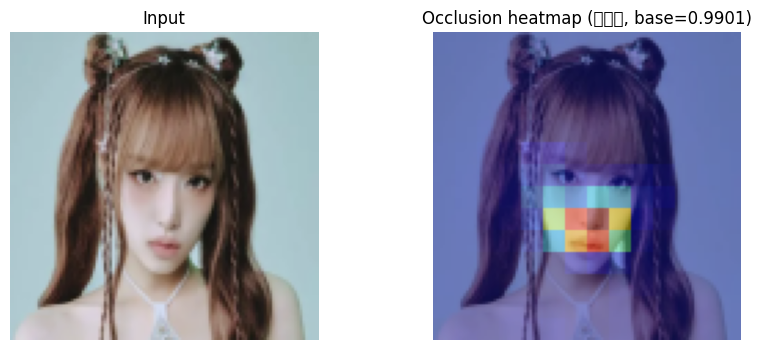

In [10]:
from pathlib import Path
import matplotlib.pyplot as plt

img_path = Path("./infer/testImg1.png")  # 필요시 변경

aligned = imread_unicode(img_path)
if aligned is None:
    raise RuntimeError(f"이미지 읽기 실패: {img_path.resolve()}")

if aligned.shape[:2] != (112, 112):
    aligned = cv2.resize(aligned, (112, 112), interpolation=cv2.INTER_AREA)

def get_class_score(model, emb_512, class_index: int):
    x = emb_512.reshape(1, -1)

    if hasattr(model, "predict_proba"):
        return float(model.predict_proba(x)[0, class_index])

    if hasattr(model, "decision_function"):
        scores = np.asarray(model.decision_function(x))
        if scores.ndim == 1:
            return float(scores[class_index] if scores.shape[0] > 1 else scores[0])
        return float(scores[0, class_index])

    pred = model.predict(x)[0]
    return float(pred == class_index)

emb0 = get_embedding_112_bgr(aligned)

if hasattr(final_model, "predict_proba"):
    probs = final_model.predict_proba(emb0.reshape(1, -1))[0]
    pred_idx = int(np.argmax(probs))
    base_score = float(probs[pred_idx])
else:
    scores = np.asarray(final_model.decision_function(emb0.reshape(1, -1)))
    if scores.ndim == 1:
        pred_idx = int(np.argmax(scores))
        base_score = float(scores[pred_idx] if scores.shape[0] > 1 else scores[0])
    else:
        pred_idx = int(np.argmax(scores[0]))
        base_score = float(scores[0, pred_idx])

pred_name = classes[pred_idx]
print("Predicted:", pred_name)

patch = 16
stride = 8
mask_value = 0

H, W = aligned.shape[:2]
heat = np.zeros((H, W), dtype=np.float32)
count = np.zeros((H, W), dtype=np.float32)

for y0 in range(0, H - patch + 1, stride):
    for x0 in range(0, W - patch + 1, stride):
        masked = aligned.copy()
        masked[y0:y0+patch, x0:x0+patch] = mask_value

        emb = get_embedding_112_bgr(masked)
        score = get_class_score(final_model, emb, pred_idx)

        drop = base_score - score
        heat[y0:y0+patch, x0:x0+patch] += drop
        count[y0:y0+patch, x0:x0+patch] += 1.0

heat = heat / np.maximum(count, 1e-6)
heat = heat - heat.min()
if heat.max() > 0:
    heat = heat / heat.max()

img_rgb = cv2.cvtColor(aligned, cv2.COLOR_BGR2RGB)
heat_u8 = (heat * 255).astype(np.uint8)
heat_color = cv2.applyColorMap(heat_u8, cv2.COLORMAP_JET)
heat_color = cv2.cvtColor(heat_color, cv2.COLOR_BGR2RGB)
overlay = cv2.addWeighted(img_rgb, 0.6, heat_color, 0.4, 0)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.title("Input")
plt.axis("off")
plt.imshow(img_rgb)

plt.subplot(1, 2, 2)
plt.title(f"Occlusion heatmap ({pred_name}, base={base_score:.4f})")
plt.axis("off")
plt.imshow(overlay)

plt.show()

### 4) 오답 이미지/결과 시각화

오답 개수: 18


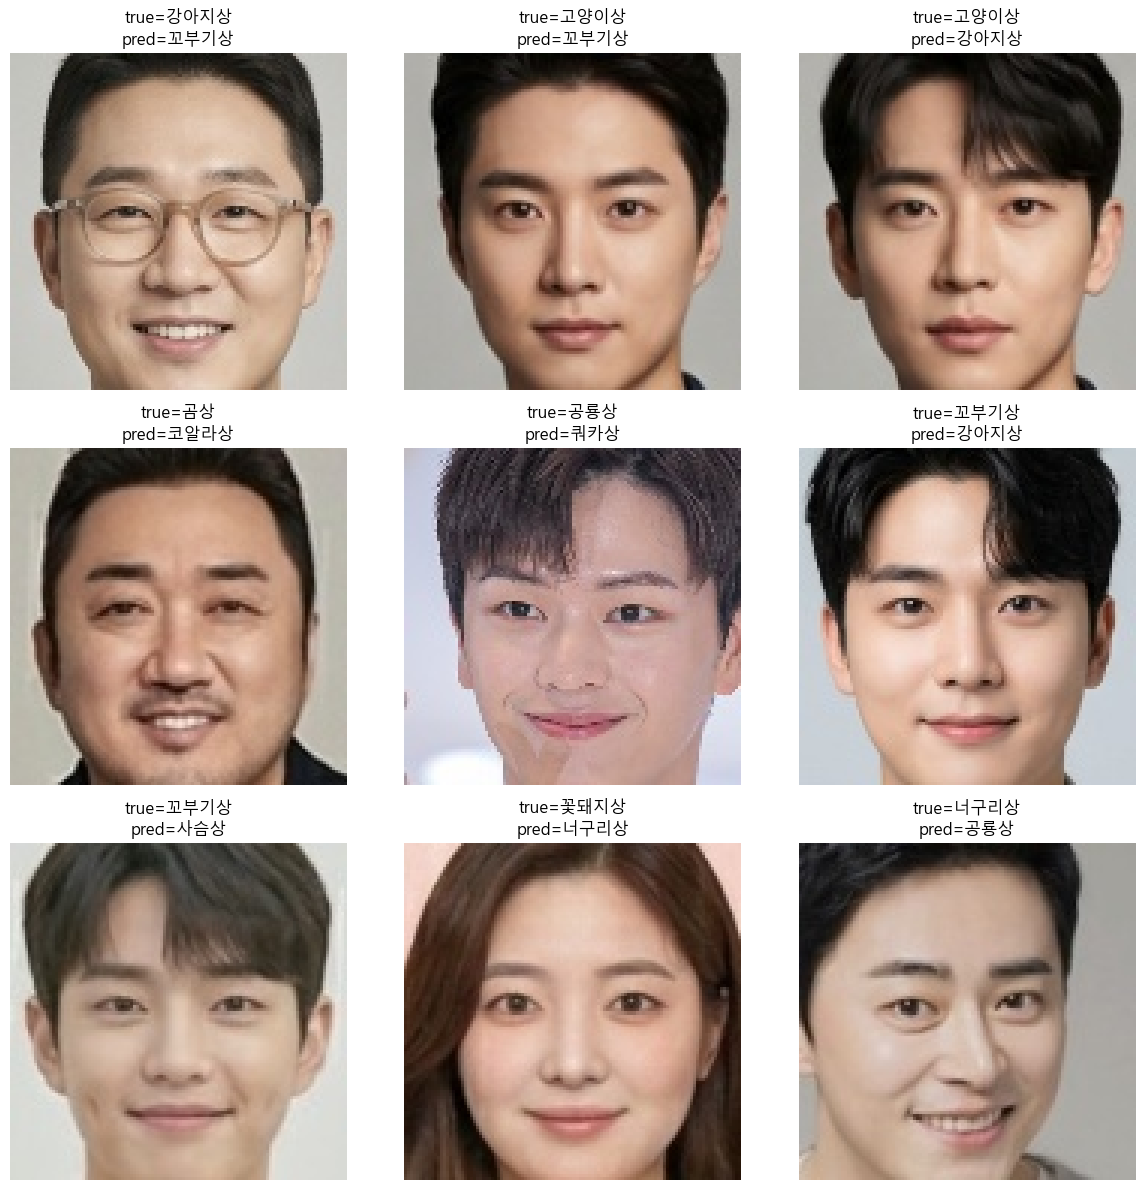

In [12]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams["font.family"] = "Malgun Gothic"
mpl.rcParams["axes.unicode_minus"] = False

def show_misclassified_examples(model, root_dir: Path, classes, max_show=9):
    samples = []

    for cls_idx, cls_name in enumerate(classes):
        cls_dir = root_dir / cls_name
        files = sorted([p for p in cls_dir.iterdir() if p.is_file() and p.suffix.lower() in IMG_EXTS])

        for p in files:
            img = imread_unicode(p)
            if img is None:
                continue

            if img.shape[:2] != (112, 112):
                img = cv2.resize(img, (112, 112), interpolation=cv2.INTER_AREA)

            emb = get_embedding_112_bgr(img).reshape(1, -1)
            pred_idx = int(model.predict(emb)[0])

            if pred_idx != cls_idx:
                samples.append((p, cls_idx, pred_idx, img))

    print("오답 개수:", len(samples))

    if not samples:
        print("오답 이미지가 없습니다.")
        return

    show_n = min(max_show, len(samples))
    cols = 3
    rows = int(np.ceil(show_n / cols))

    plt.figure(figsize=(12, 4 * rows))
    for i in range(show_n):
        p, true_idx, pred_idx, img112 = samples[i]
        img_rgb = cv2.cvtColor(img112, cv2.COLOR_BGR2RGB)

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img_rgb)
        plt.axis("off")
        plt.title(f"true={classes[true_idx]}\npred={classes[pred_idx]}")

    plt.tight_layout()
    plt.show()

show_misclassified_examples(final_model, TEST_DIR, classes, max_show=9)

## 5. 모델 저장

In [13]:
import joblib
from pathlib import Path

MODEL_DIR = Path("model")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(
    {"model": final_model, "classes": classes},
    MODEL_DIR / "animal_face_final_final.joblib"
)

print("saved:", (MODEL_DIR / "animal_face_final_final.joblib").resolve())

saved: C:\workspace\project2\gachikium\유현희\model\animal_face_final_final.joblib


## 6. 예측

### 1) 얼굴 전처리 공통 함수

In [14]:
import cv2, numpy as np, joblib
from pathlib import Path
from insightface.app import FaceAnalysis
from insightface.utils.face_align import norm_crop

IMG_EXTS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

def imread_unicode(path: Path):
    data = np.fromfile(str(path), dtype=np.uint8)
    return cv2.imdecode(data, cv2.IMREAD_COLOR)

def l2_normalize(x):
    return x / (np.linalg.norm(x) + 1e-12)

bundle = joblib.load("model/animal_face_final_final.joblib")
pred_model = bundle["model"]
pred_classes = bundle["classes"]

pred_app = FaceAnalysis(name="buffalo_l")
pred_app.prepare(ctx_id=0, det_size=(640, 640))

pred_rec = pred_app.models.get("recognition")
if pred_rec is None:
    raise RuntimeError(f"recognition model not found. keys={list(pred_app.models.keys())}")

def face_to_112(img_bgr):
    faces = pred_app.get(img_bgr)
    if not faces:
        return None

    face = max(faces, key=lambda f: (f.bbox[2]-f.bbox[0])*(f.bbox[3]-f.bbox[1]))

    if getattr(face, "kps", None) is not None:
        return norm_crop(img_bgr, face.kps)
    else:
        x1, y1, x2, y2 = map(int, face.bbox)
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = max(0, x2), max(0, y2)
        crop = img_bgr[y1:y2, x1:x2]
        if crop.size == 0:
            return None
        return cv2.resize(crop, (112, 112), interpolation=cv2.INTER_AREA)

def get_pred_embedding_112_bgr(img_112):
    if hasattr(pred_rec, "get_feat"):
        emb = pred_rec.get_feat(img_112)
        emb = np.asarray(emb).reshape(-1)
    else:
        raise RuntimeError("pred_rec.get_feat not found.")
    return l2_normalize(emb).astype(np.float32)

Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CUDAExecutionProvider': {'device_id': '0', 'has_user_compute_stream': '0', 'cudnn_conv1d_pad_to_nc1d': '0', 'user_compute_stream': '0', 'gpu_external_alloc': '0', 'gpu_mem_limit': '18446744073709551615', 'enable_cuda_graph': '0', 'gpu_external_free': '0', 'gpu_external_empty_cache': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'do_copy_in_default_stream': '1', 'cudnn_conv_use_max_workspace': '1', 'tunable_op_enable': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'prefer_nhwc': '0', 'use_ep_level_unified_stream': '0', 'use_tf32': '1', 'sdpa_kernel': '0', 'fuse_conv_bias': '0'}, 'CPUExecutionProvider': {}}
find model: C:\Users\user/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider']

### 2) 얼굴 전처리 공통 함수 사용하여 학습 데이터 로딩
- 예측 시 얼굴 전처리 공통 함수(face_to_112, get_pred_embedding_112_bgr)를 사용

### 3) 예측할 폴더

In [17]:
def topk_candidates_from_model(model, emb_1x512, classes, k=3):
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(emb_1x512)[0]
        idxs = np.argsort(-proba)[:k]
        return [(classes[i], float(proba[i])) for i in idxs]

    if hasattr(model, "decision_function"):
        scores = model.decision_function(emb_1x512)
        scores = np.asarray(scores)

        if scores.ndim == 1:
            idxs = np.argsort(-scores)[:k]
            return [(classes[i], float(scores[i])) for i in idxs]
        else:
            idxs = np.argsort(-scores[0])[:k]
            return [(classes[i], float(scores[0, i])) for i in idxs]

    pred_idx = int(model.predict(emb_1x512)[0])
    return [(classes[pred_idx], 1.0)]

def predict_one(image_path: str, topk=3):
    p = Path(image_path)
    img = imread_unicode(p)
    if img is None:
        return {"path": str(p), "ok": False, "reason": "failed_to_read"}

    img112 = face_to_112(img)
    if img112 is None:
        return {"path": str(p), "ok": False, "reason": "no_face_detected"}

    emb = get_pred_embedding_112_bgr(img112)
    emb_1x = emb.reshape(1, -1)

    pred_idx = int(pred_model.predict(emb_1x)[0])
    pred_name = pred_classes[pred_idx]
    topk_list = topk_candidates_from_model(pred_model, emb_1x, pred_classes, k=topk)

    return {
        "path": str(p),
        "ok": True,
        "pred": pred_name,
        "topk": topk_list,
    }

def predict_path(path: str, topk=3, recursive=True):
    p = Path(path)

    if p.is_file():
        return [predict_one(str(p), topk=topk)]

    if p.is_dir():
        it = p.rglob("*") if recursive else p.glob("*")
        files = [x for x in it if x.is_file() and x.suffix.lower() in IMG_EXTS]
        files.sort(key=lambda x: str(x))
        return [predict_one(str(f), topk=topk) for f in files]

    raise FileNotFoundError(f"not found: {p}")

def print_prediction_results(results):
    for i, r in enumerate(results, start=1):
        print("=" * 70)
        print(f"[{i}] 파일 경로 : {r['path']}")
        print(f"처리 성공    : {r['ok']}")

        if not r["ok"]:
            print(f"실패 이유    : {r['reason']}")
            continue

        print(f"예측 클래스  : {r['pred']}")
        print("[top-k 후보]")
        for rank, (name, score) in enumerate(r["topk"], start=1):
            print(f"  {rank}. {name:10s} | score = {score:.6f}")
    print("=" * 70)

results = predict_path("./infer/new_test", topk=3)
print_prediction_results(results)

c:\workspace\project2\gachikium\.venv\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)
c:\workspace\project2\gachikium\.venv\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)
c:\workspace\project2\gachikium\.venv\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


[1] 파일 경로 : infer\new_test\testImg1.png
처리 성공    : True
예측 클래스  : 고양이상
[top-k 후보]
  1. 고양이상       | score = 0.503052
  2. 꽃돼지상       | score = 0.177147
  3. 도롱뇽상       | score = 0.161154
[2] 파일 경로 : infer\new_test\testImg2.png
처리 성공    : True
예측 클래스  : 꽃돼지상
[top-k 후보]
  1. 꽃돼지상       | score = 0.782169
  2. 오리상        | score = 0.067232
  3. 알파카상, 라마상  | score = 0.047420
[3] 파일 경로 : infer\new_test\testImg3.png
처리 성공    : True
예측 클래스  : 오리상
[top-k 후보]
  1. 오리상        | score = 0.457221
  2. 꽃돼지상       | score = 0.365927
  3. 너구리상       | score = 0.136313
[4] 파일 경로 : infer\new_test\testImg4.png
처리 성공    : True
예측 클래스  : 햄스터상
[top-k 후보]
  1. 햄스터상       | score = 0.612746
  2. 늑대상        | score = 0.257179
  3. 알파카상, 라마상  | score = 0.106060
[5] 파일 경로 : infer\new_test\testImg5.png
처리 성공    : True
예측 클래스  : 곰상
[top-k 후보]
  1. 곰상         | score = 0.404287
  2. 토끼상        | score = 0.194854
  3. 오리상        | score = 0.129913
[6] 파일 경로 : infer\new_test\testImg6.png
처리 성공    : True
예측 클래스  : 여우

c:\workspace\project2\gachikium\.venv\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)
c:\workspace\project2\gachikium\.venv\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)
c:\workspace\project2\gachikium\.venv\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)
c:\workspace\project2\gachikium\.venv\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated sinc

## 7. 혼동이 많이 발생한 클래스 확인

In [20]:
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
import numpy as np

# 예측
y_pred = final_model.predict(X_test)

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=classes, columns=classes)

print("[Classification Report]")
print(classification_report(y_test, y_pred, target_names=classes))

print("\n[Confusion Matrix]")
display(cm_df)

# 클래스별 혼동 요약
row_sum = cm.sum(axis=1)
diag = np.diag(cm)
wrong = row_sum - diag
recall = diag / row_sum

summary_df = pd.DataFrame({
    "class": classes,
    "total": row_sum,
    "correct": diag,
    "wrong": wrong,
    "recall": recall
}).sort_values(by=["recall", "wrong"], ascending=[True, False])

print("\n[혼동 많은 클래스 요약]")
display(summary_df)

confused_classes = summary_df.head(4)["class"].tolist()
print("혼동이 많이 발생한 클래스 TOP 4:", confused_classes)

[Classification Report]
              precision    recall  f1-score   support

        강아지상       0.69      0.90      0.78        10
        고양이상       1.00      0.80      0.89        10
          곰상       0.90      0.90      0.90        10
         공룡상       0.90      0.90      0.90        10
        꼬부기상       0.80      0.80      0.80        10
        꽃돼지상       0.90      0.90      0.90        10
        너구리상       0.88      0.70      0.78        10
         늑대상       1.00      1.00      1.00        10
        도롱뇽상       0.91      1.00      0.95        10
          말상       1.00      1.00      1.00        10
         사슴상       0.82      0.90      0.86        10
   알파카상, 라마상       1.00      0.80      0.89        10
         여우상       1.00      1.00      1.00        10
         오리상       1.00      1.00      1.00        10
         원숭이       1.00      1.00      1.00        10
          쥐상       0.89      0.80      0.84        10
        코알라상       0.91      1.00      0.95        10
   

,강아지상,고양이상,곰상,공룡상,꼬부기상,꽃돼지상,너구리상,늑대상,도롱뇽상,말상,사슴상,"알파카상, 라마상",여우상,오리상,원숭이,쥐상,코알라상,쿼카상,토끼상,햄스터상
강아지상,9,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
고양이상,1,8,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
곰상,0,0,9,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
공룡상,0,0,0,9,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
꼬부기상,1,0,0,0,8,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
꽃돼지상,0,0,0,0,0,9,1,0,0,0,0,0,0,0,0,0,0,0,0,0
너구리상,0,0,1,1,0,1,7,0,0,0,0,0,0,0,0,0,0,0,0,0
늑대상,0,0,0,0,0,0,0,10,0,0,0,0,0,0,0,0,0,0,0,0
도롱뇽상,0,0,0,0,0,0,0,0,10,0,0,0,0,0,0,0,0,0,0,0
말상,0,0,0,0,0,0,0,0,0,10,0,0,0,0,0,0,0,0,0,0



[혼동 많은 클래스 요약]


,class,total,correct,wrong,recall
6,너구리상,10,7,3,0.7
1,고양이상,10,8,2,0.8
4,꼬부기상,10,8,2,0.8
11,"알파카상, 라마상",10,8,2,0.8
15,쥐상,10,8,2,0.8
0,강아지상,10,9,1,0.9
2,곰상,10,9,1,0.9
3,공룡상,10,9,1,0.9
5,꽃돼지상,10,9,1,0.9
10,사슴상,10,9,1,0.9


혼동이 많이 발생한 클래스 TOP 4: ['너구리상', '고양이상', '꼬부기상', '알파카상, 라마상']


In [22]:
print(results[0].keys())
print(results[0])

dict_keys(['path', 'ok', 'pred', 'topk'])
{'path': 'infer\\new_test\\testImg1.png', 'ok': True, 'pred': '고양이상', 'topk': [('고양이상', 0.5030520808857706), ('꽃돼지상', 0.17714665194388804), ('도롱뇽상', 0.16115394879134975)]}


[1] path       : infer\new_test\testImg1.png
pred class     : 고양이상
[top-k 후보]
  1. 고양이상       | score = 0.503052
  2. 꽃돼지상       | score = 0.177147
  3. 도롱뇽상       | score = 0.161154


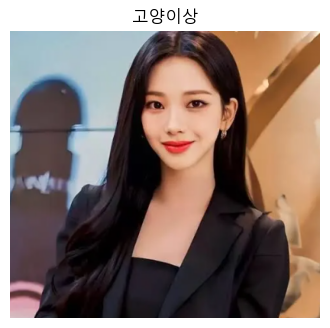

[2] path       : infer\new_test\testImg2.png
pred class     : 꽃돼지상
[top-k 후보]
  1. 꽃돼지상       | score = 0.782169
  2. 오리상        | score = 0.067232
  3. 알파카상, 라마상  | score = 0.047420


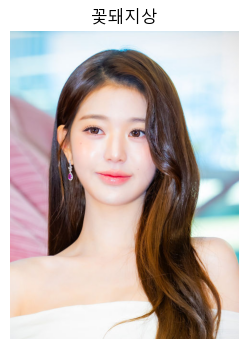

[3] path       : infer\new_test\testImg3.png
pred class     : 오리상
[top-k 후보]
  1. 오리상        | score = 0.457221
  2. 꽃돼지상       | score = 0.365927
  3. 너구리상       | score = 0.136313


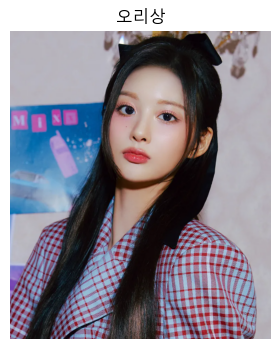

[4] path       : infer\new_test\testImg4.png
pred class     : 햄스터상
[top-k 후보]
  1. 햄스터상       | score = 0.612746
  2. 늑대상        | score = 0.257179
  3. 알파카상, 라마상  | score = 0.106060


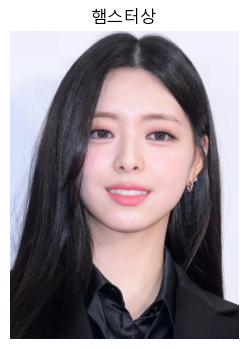

[5] path       : infer\new_test\testImg5.png
pred class     : 곰상
[top-k 후보]
  1. 곰상         | score = 0.404287
  2. 토끼상        | score = 0.194854
  3. 오리상        | score = 0.129913


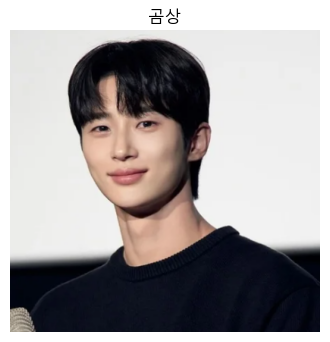

[6] path       : infer\new_test\testImg6.png
pred class     : 여우상
[top-k 후보]
  1. 여우상        | score = 0.348753
  2. 공룡상        | score = 0.341165
  3. 원숭이        | score = 0.145099


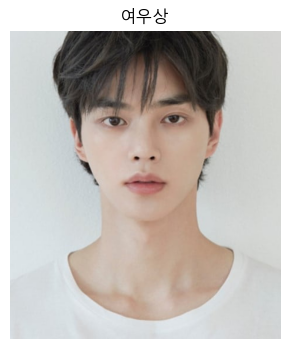

[7] path       : infer\new_test\testImg7.png
pred class     : 늑대상
[top-k 후보]
  1. 늑대상        | score = 0.789375
  2. 햄스터상       | score = 0.102735
  3. 곰상         | score = 0.066277


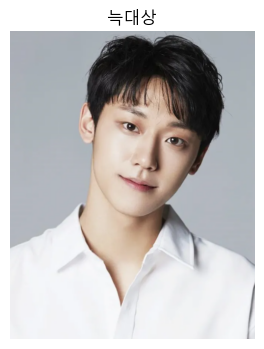

[8] path       : infer\new_test\testImg8.png
pred class     : 햄스터상
[top-k 후보]
  1. 햄스터상       | score = 0.927893
  2. 늑대상        | score = 0.037093
  3. 말상         | score = 0.007529


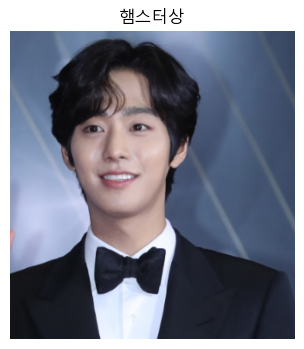

In [26]:
def show_prediction_results_with_image(results, max_show=None):
    valid_results = [r for r in results if r.get("ok")]

    if max_show is not None:
        valid_results = valid_results[:max_show]

    for i, r in enumerate(valid_results, start=1):
        print("=" * 100)
        print(f"[{i}] path       : {r['path']}")
        print(f"pred class     : {r['pred']}")
        print("[top-k 후보]")
        for rank, (name, score) in enumerate(r["topk"], start=1):
            print(f"  {rank}. {name:10s} | score = {score:.6f}")

        img = imread_unicode(r["path"])
        if img is not None:
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            plt.figure(figsize=(4, 4))
            plt.title(r["pred"])
            plt.axis("off")
            plt.imshow(img_rgb)
            plt.show()

show_prediction_results_with_image(results)

## 8. 과적합 여부 확인

In [27]:
from sklearn.metrics import accuracy_score

train_pred = final_model.predict(X_train)
test_pred = final_model.predict(X_test)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)
print("Gap:", train_acc - test_acc)

Train Accuracy: 1.0
Test Accuracy: 0.91
Gap: 0.08999999999999997


- Train Accuracy = 1.0
→ 학습 데이터는 전부 맞춤
- Test Accuracy = 0.91
→ 새로운 데이터에서는 91%
- Gap = 0.09
→ 성능 차이가 9%p